<a href="https://colab.research.google.com/github/jenny005/Latent_Distances/blob/main/exp1_latent_geometry_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1: Latent-Euclidean vs Geometric vs Observation error

**Central hypothesis:** $E_{\text{latent}}$ alone does not capture rollout failure. The pullback-metric error
$$E_{\text{geom}} = \|J_D(\hat z)\,(\hat z - z^{\text{true}})\|^2 = \Delta z^\top G(z)\, \Delta z$$
carries information about observation error that latent Euclidean distance misses.

## Pipeline
1. Generate Lorenz-63 trajectories (3D).
2. Lift to 64D observations via a fixed heterogeneous nonlinear map (RBF + Fourier + polynomial features).
3. Train an MLP autoencoder (64 ↔ 16) + an MLP latent dynamics model.
4. Run held-out multi-step rollouts.
5. At each step compute $E_{\text{latent}}$, $E_{\text{geom}}$, $E_{\text{obs}}$.
6. Test: global correlation, time-binned correlation, **partial correlation** (the key test).

Deterministic decoder ⇒ Fisher metric reduces to pullback $G = J_D^\top J_D$, so $E_{\text{geom}}$ is one JVP per step — no need to materialize the Jacobian.

## 1. Imports & config

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

torch.manual_seed(0)
np.random.seed(0)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LATENT_DIM = 16
OBS_DIM = 64
print(f'device: {DEVICE}, latent_dim={LATENT_DIM}, obs_dim={OBS_DIM}')

device: cuda, latent_dim=16, obs_dim=64


## 2. Lorenz data

RK4 integrator with burn-in to settle onto the attractor.

In [ ]:
def lorenz_rhs(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state[..., 0], state[..., 1], state[..., 2]
    return np.stack([sigma*(y-x), x*(rho-z)-y, x*y-beta*z], axis=-1)

def rk4_step(state, dt):
    k1 = lorenz_rhs(state)
    k2 = lorenz_rhs(state + 0.5*dt*k1)
    k3 = lorenz_rhs(state + 0.5*dt*k2)
    k4 = lorenz_rhs(state + dt*k3)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def generate_lorenz_trajectories(n_traj, n_steps, dt=0.01, burn_in=500):
    states = np.random.randn(n_traj, 3) * 5.0
    for _ in range(burn_in):
        states = rk4_step(states, dt)
    trajs = np.zeros((n_traj, n_steps, 3))
    trajs[:, 0] = states
    for t in range(1, n_steps):
        trajs[:, t] = rk4_step(trajs[:, t-1], dt)
    return trajs.astype(np.float32)

train: (200, 200, 3), test: (100, 400, 3)


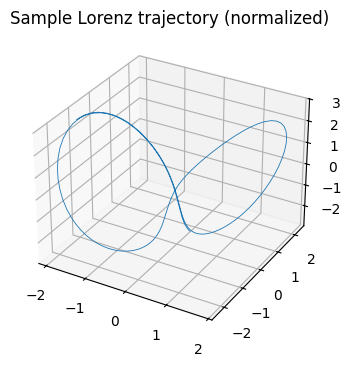

In [ ]:
# Generate trajectories
n_train, n_test = 200, 100
T_train, T_test = 200, 400
dt = 0.01

traj_train = generate_lorenz_trajectories(n_train, T_train, dt=dt)
traj_test  = generate_lorenz_trajectories(n_test,  T_test,  dt=dt)

# Normalize using training stats
mean = traj_train.reshape(-1, 3).mean(axis=0)
std  = traj_train.reshape(-1, 3).std(axis=0)
traj_train = (traj_train - mean) / std
traj_test  = (traj_test  - mean) / std

print(f'train: {traj_train.shape}, test: {traj_test.shape}')

# Sanity plot
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj_train[0, :, 0], traj_train[0, :, 1], traj_train[0, :, 2], lw=0.6)
ax.set_title('Sample Lorenz trajectory (normalized)')
plt.show()

## 3. Random nonlinear lift $\mathbb{R}^3 \to \mathbb{R}^{64}$

**Why heterogeneous features matter.** If the lift were globally smooth (e.g. a single $\tanh$ MLP), the trained decoder would learn a near-isometric inverse and local sensitivity would be uniform across the attractor — in which case $E_{\text{geom}} \propto E_{\text{latent}}$ trivially and there is nothing to diagnose.

The RBF + Fourier + polynomial mix creates regions of expansion and contraction on the attractor, which is what the theory is about. This mimics PDE/image data where observation-space sensitivity varies dramatically across the data manifold.

In [ ]:
class RandomLift(nn.Module):
    """Fixed nonlinear lift with heterogeneous local sensitivity."""
    def __init__(self, in_dim=3, out_dim=64, n_rbf=32, n_freq=24, seed=42):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.centers = nn.Parameter(torch.randn(n_rbf, in_dim, generator=g) * 1.5,
                                    requires_grad=False)
        self.widths  = nn.Parameter(0.3 + 0.7 * torch.rand(n_rbf, generator=g),
                                    requires_grad=False)
        self.freqs   = nn.Parameter(torch.randn(n_freq, in_dim, generator=g) * 1.2,
                                    requires_grad=False)
        self.phases  = nn.Parameter(2 * math.pi * torch.rand(n_freq, generator=g),
                                    requires_grad=False)
        feat_dim = n_rbf + n_freq + 4
        self.W = nn.Parameter(torch.randn(feat_dim, out_dim, generator=g) / math.sqrt(feat_dim),
                              requires_grad=False)

    def forward(self, x):
        d2 = ((x.unsqueeze(-2) - self.centers) ** 2).sum(dim=-1)
        rbf = torch.exp(-d2 / (2 * self.widths ** 2))
        phase = x @ self.freqs.T + self.phases
        fourier = torch.cos(phase)
        r = x.norm(dim=-1, keepdim=True)
        poly = torch.cat([r, r**2,
                          (x[..., 0] * x[..., 1]).unsqueeze(-1),
                          (x[..., 1] * x[..., 2]).unsqueeze(-1)], dim=-1)
        feats = torch.cat([rbf, fourier, poly], dim=-1)
        return feats @ self.W

lift = RandomLift(in_dim=3, out_dim=OBS_DIM).to(DEVICE)
with torch.no_grad():
    obs_train = lift(torch.from_numpy(traj_train).to(DEVICE))
    obs_test  = lift(torch.from_numpy(traj_test).to(DEVICE))
print(f'obs_train: {obs_train.shape}, obs_test: {obs_test.shape}')

obs_train: torch.Size([200, 200, 64]), obs_test: torch.Size([100, 400, 64])


## 4. Autoencoder + latent dynamics

Standard architecture — no geometry-awareness in the model itself. The whole point is to diagnose how a *typical* latent dynamics model behaves under the geometric lens.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, obs_dim=OBS_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, latent_dim),
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, obs_dim=OBS_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, obs_dim),
        )
    def forward(self, z):
        return self.net(z)

class LatentDynamics(nn.Module):
    """Residual one-step predictor: z_{t+1} = z_t + f(z_t)."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, latent_dim),
        )
    def forward(self, z):
        return z + self.net(z)

## 5. Training

Three standard losses: reconstruction, latent dynamics, and one-step decoded prediction. Nothing exotic — a reviewer should look at this and say "yes, this is a representative latent dynamics model."

training on 39800 pairs for 30 epochs...
  epoch   1/30  loss=0.64185
  epoch   5/30  loss=0.02190
  epoch  10/30  loss=0.00471
  epoch  15/30  loss=0.00223
  epoch  20/30  loss=0.00130
  epoch  25/30  loss=0.00092
  epoch  30/30  loss=0.00066


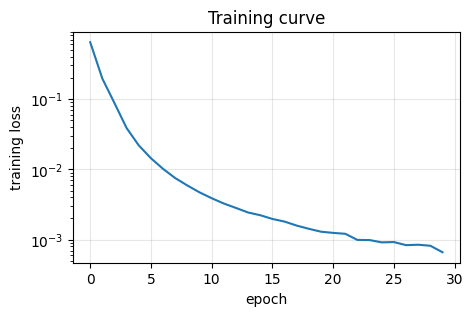

In [ ]:
def train_model(obs_train, n_epochs=30, batch_size=512, lr=1e-3):
    enc = Encoder().to(DEVICE)
    dec = Decoder().to(DEVICE)
    dyn = LatentDynamics().to(DEVICE)
    params = list(enc.parameters()) + list(dec.parameters()) + list(dyn.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    n_traj, T, _ = obs_train.shape
    x_t   = obs_train[:, :-1].reshape(-1, OBS_DIM)
    x_tp1 = obs_train[:, 1:].reshape(-1, OBS_DIM)
    N = x_t.shape[0]
    print(f'training on {N} pairs for {n_epochs} epochs...')

    history = []
    for epoch in range(n_epochs):
        perm = torch.randperm(N, device=DEVICE)
        total = 0.0; n_batches = 0
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            x0, x1 = x_t[idx], x_tp1[idx]
            z0 = enc(x0); z1 = enc(x1)
            z1_pred = dyn(z0)
            x0_rec  = dec(z0); x1_rec = dec(z1); x1_pred = dec(z1_pred)
            loss = (((x0_rec - x0)**2).mean() + ((x1_rec - x1)**2).mean()
                    + ((z1_pred - z1)**2).mean() + ((x1_pred - x1)**2).mean())
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
            total += loss.item(); n_batches += 1
        avg = total / n_batches
        history.append(avg)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  epoch {epoch+1:3d}/{n_epochs}  loss={avg:.5f}')
    return enc, dec, dyn, history

enc, dec, dyn, history = train_model(obs_train, n_epochs=30)
enc.eval(); dec.eval(); dyn.eval()

plt.figure(figsize=(5, 3))
plt.semilogy(history)
plt.xlabel('epoch'); plt.ylabel('training loss'); plt.grid(alpha=0.3)
plt.title('Training curve'); plt.show()

## 6. The heart of the experiment: compute the three errors

For each held-out trajectory, do a free rollout starting from the encoded initial state and at every step record:

- $E_{\text{latent}}(t) = \|\hat z_t - z_t^{\text{true}}\|^2$
- $E_{\text{geom}}(t)\,= \|J_D(\hat z_t)\,(\hat z_t - z_t^{\text{true}})\|^2$ — computed as a single JVP
- $E_{\text{obs}}(t)\;\;= \|D(\hat z_t) - x_t^{\text{true}}\|^2$

The JVP trick avoids ever forming the $D \times d$ Jacobian matrix.

In [ ]:
def compute_errors_for_trajectory(enc, dec, dyn, obs_traj):
    """obs_traj: (T, OBS_DIM). Returns E_latent, E_geom, E_obs, t_index."""
    T = obs_traj.shape[0]
    with torch.no_grad():
        z_true = enc(obs_traj)
    # free rollout from z_true[0]
    z_hats = [z_true[0]]
    with torch.no_grad():
        for t in range(1, T):
            z_hats.append(dyn(z_hats[-1].unsqueeze(0)).squeeze(0))
    z_hat = torch.stack(z_hats, dim=0)

    delta_z  = z_hat - z_true
    E_latent = (delta_z ** 2).sum(dim=-1)

    with torch.no_grad():
        E_obs = ((dec(z_hat) - obs_traj) ** 2).sum(dim=-1)

    E_geom = torch.zeros(T)
    for t in range(T):
        zt = z_hat[t].detach()
        v  = delta_z[t].detach()
        _, jvp_out = jvp(dec, (zt.unsqueeze(0),), (v.unsqueeze(0),))
        E_geom[t] = (jvp_out ** 2).sum().item()

    t_idx = np.arange(T)
    return (E_latent.detach().cpu().numpy(),
            E_geom.detach().cpu().numpy(),
            E_obs.detach().cpu().numpy(),
            t_idx)

# Run over held-out trajectories
all_lat, all_geom, all_obs, all_t = [], [], [], []
n_eval = 50
for i in range(n_eval):
    el, eg, eo, ti = compute_errors_for_trajectory(enc, dec, dyn, obs_test[i])
    all_lat.append(el[1:]); all_geom.append(eg[1:])
    all_obs.append(eo[1:]); all_t.append(ti[1:])
    if (i + 1) % 10 == 0:
        print(f'rolled out {i+1}/{n_eval}')

E_lat  = np.concatenate(all_lat)
E_geom = np.concatenate(all_geom)
E_obs  = np.concatenate(all_obs)
T_idx  = np.concatenate(all_t)

eps = 1e-12
mask = (E_lat > eps) & (E_geom > eps) & (E_obs > eps)
E_lat, E_geom, E_obs, T_idx = E_lat[mask], E_geom[mask], E_obs[mask], T_idx[mask]
print(f'kept {mask.sum()}/{mask.shape[0]} points')

rolled out 10/50
rolled out 20/50
rolled out 30/50
rolled out 40/50
rolled out 50/50
kept 19950/19950 points


## 7. Correlation analysis

Three levels of rigor:

1. **Global correlation** — weak test, dominated by error growth over time (any monotone-in-time quantity will look correlated with $E_{\text{obs}}$).
2. **Time-binned correlation** — controls for rollout horizon. Within a narrow time window, error magnitudes are comparable and the test becomes discriminating.
3. **Partial correlation** — regress out latent error, then ask: does geometric error still explain residual observation error?

Test #3 is the strongest statistical statement.

In [ ]:
# Global Spearman correlations
rho_lat_obs,  _ = spearmanr(np.log(E_lat),  np.log(E_obs))
rho_geom_obs, _ = spearmanr(np.log(E_geom), np.log(E_obs))
rho_lat_geom, _ = spearmanr(np.log(E_lat),  np.log(E_geom))

print('=== global Spearman correlations (log space) ===')
print(f'  rho(E_latent, E_obs)  = {rho_lat_obs:.4f}')
print(f'  rho(E_geom,   E_obs)  = {rho_geom_obs:.4f}')
print(f'  rho(E_latent, E_geom) = {rho_lat_geom:.4f}')
print('  (These are dominated by error growth over time.)')

=== global Spearman correlations (log space) ===
  rho(E_latent, E_obs)  = 0.9996
  rho(E_geom,   E_obs)  = 0.9999
  rho(E_latent, E_geom) = 0.9996
  (These are dominated by error growth over time.)


In [ ]:
# Time-binned correlations
print('=== time-binned correlations (controls for time confound) ===')
print(f"  {'t bin':>10s}  {'n':>6s}  {'rho(lat,obs)':>14s}  {'rho(geom,obs)':>14s}  {'advantage':>10s}")
bins = [(1, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
bin_results = []
for lo, hi in bins:
    m = (T_idx >= lo) & (T_idx < hi)
    if m.sum() < 50:
        continue
    r_l, _ = spearmanr(np.log(E_lat[m]),  np.log(E_obs[m]))
    r_g, _ = spearmanr(np.log(E_geom[m]), np.log(E_obs[m]))
    bin_results.append((lo, hi, m.sum(), r_l, r_g, r_g - r_l))
    print(f'  [{lo:4d},{hi:4d})  {m.sum():6d}  {r_l:14.4f}  {r_g:14.4f}  {r_g - r_l:+10.4f}')

=== time-binned correlations (controls for time confound) ===
       t bin       n    rho(lat,obs)   rho(geom,obs)   advantage
  [   1,  25)    1200          0.9328          0.9644     +0.0317
  [  25,  50)    1250          0.9476          0.9961     +0.0485
  [  50, 100)    2500          0.9748          0.9970     +0.0222
  [ 100, 200)    5000          0.9984          0.9993     +0.0010
  [ 200, 400)   10000          0.9998          1.0000     +0.0002


In [ ]:
# Partial correlation: rho(E_geom, E_obs | E_lat)
def residualize(y, x):
    X = np.stack([np.ones_like(x), x], axis=1)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ coef

log_lat  = np.log(E_lat)
log_geom = np.log(E_geom)
log_obs  = np.log(E_obs)
log_obs_res  = residualize(log_obs,  log_lat)
log_geom_res = residualize(log_geom, log_lat)
rho_partial, _ = spearmanr(log_geom_res, log_obs_res)
print(f'=== partial correlation rho(E_geom, E_obs | E_lat) = {rho_partial:.4f} ===')
print('  Positive => geometry explains observation error beyond what latent norm does.')

=== partial correlation rho(E_geom, E_obs | E_lat) = 0.8668 ===
  Positive => geometry explains observation error beyond what latent norm does.


## 8. Diagnostic plots

Four panels:
1. Naive $E_{\text{latent}}$ vs $E_{\text{obs}}$, colored by time.
2. Geometric $E_{\text{geom}}$ vs $E_{\text{obs}}$, colored by time.
3. Time-binned correlation bar chart.
4. **Partial correlation scatter — the headline figure.**

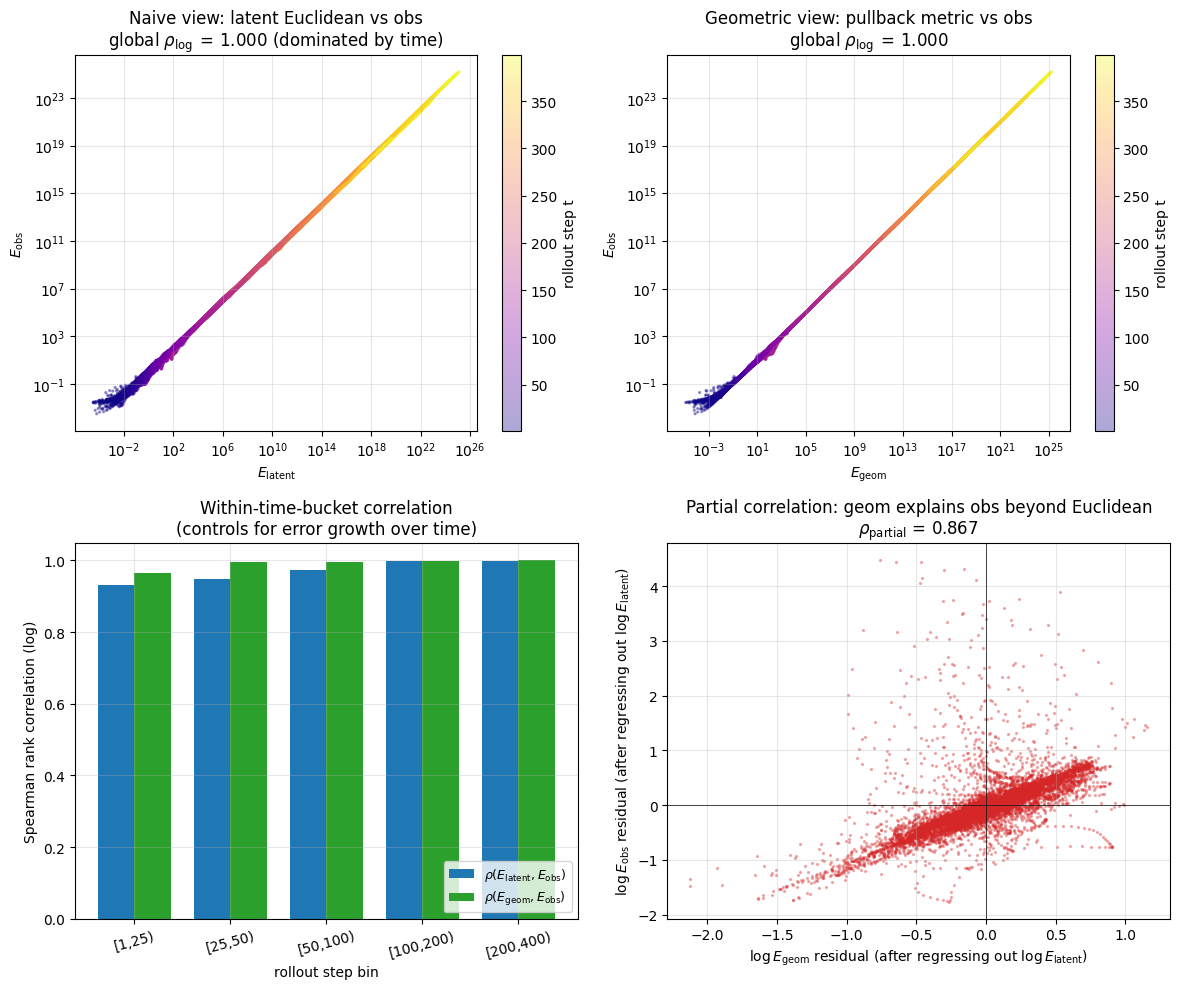

saved exp1_diagnostic_plots.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: E_latent vs E_obs colored by time
ax = axes[0, 0]
sc = ax.scatter(E_lat, E_obs, s=2, alpha=0.35, c=T_idx, cmap='plasma')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$E_{\mathrm{latent}}$')
ax.set_ylabel(r'$E_{\mathrm{obs}}$')
ax.set_title('Naive view: latent Euclidean vs obs\n' +
             r'global $\rho_{\log}$ = ' + f'{rho_lat_obs:.3f} (dominated by time)')
plt.colorbar(sc, ax=ax, label='rollout step t')
ax.grid(True, which='both', alpha=0.3)

# Plot 2: E_geom vs E_obs colored by time
ax = axes[0, 1]
sc = ax.scatter(E_geom, E_obs, s=2, alpha=0.35, c=T_idx, cmap='plasma')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$E_{\mathrm{geom}}$')
ax.set_ylabel(r'$E_{\mathrm{obs}}$')
ax.set_title('Geometric view: pullback metric vs obs\n' +
             r'global $\rho_{\log}$ = ' + f'{rho_geom_obs:.3f}')
plt.colorbar(sc, ax=ax, label='rollout step t')
ax.grid(True, which='both', alpha=0.3)

# Plot 3: time-binned correlation bars
ax = axes[1, 0]
if bin_results:
    labels = [f'[{lo},{hi})' for lo, hi, *_ in bin_results]
    x_pos = np.arange(len(labels))
    r_lat_arr  = [r[3] for r in bin_results]
    r_geom_arr = [r[4] for r in bin_results]
    width = 0.38
    ax.bar(x_pos - width/2, r_lat_arr,  width, label=r'$\rho(E_{\mathrm{latent}}, E_{\mathrm{obs}})$', color='C0')
    ax.bar(x_pos + width/2, r_geom_arr, width, label=r'$\rho(E_{\mathrm{geom}}, E_{\mathrm{obs}})$',  color='C2')
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel('Spearman rank correlation (log)')
    ax.set_xlabel('rollout step bin')
    ax.set_title('Within-time-bucket correlation\n(controls for error growth over time)')
    ax.axhline(0, color='k', lw=0.5); ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

# Plot 4: partial correlation (the headline)
ax = axes[1, 1]
ax.scatter(log_geom_res, log_obs_res, s=2, alpha=0.3, c='C3')
ax.set_xlabel(r'$\log E_{\mathrm{geom}}$ residual (after regressing out $\log E_{\mathrm{latent}}$)')
ax.set_ylabel(r'$\log E_{\mathrm{obs}}$ residual (after regressing out $\log E_{\mathrm{latent}}$)')
ax.set_title('Partial correlation: geom explains obs beyond Euclidean\n' +
             r'$\rho_{\mathrm{partial}}$ = ' + f'{rho_partial:.3f}')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exp1_diagnostic_plots.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved exp1_diagnostic_plots.png')

## 9. Save results & summary

In [ ]:
np.savez('exp1_errors.npz',
         E_latent=E_lat, E_geom=E_geom, E_obs=E_obs, t_idx=T_idx,
         rho_lat_obs=rho_lat_obs, rho_geom_obs=rho_geom_obs,
         rho_partial=rho_partial)
print('saved exp1_errors.npz')

print('\n=== summary ===')
print(f'  rho(latent, obs) global:           {rho_lat_obs:+.4f}')
print(f'  rho(geom,   obs) global:           {rho_geom_obs:+.4f}')
print(f'  partial rho(geom, obs | latent):   {rho_partial:+.4f}   <-- key result')
print('  --- by time bin ---')
for lo, hi, n, r_l, r_g, adv in bin_results:
    print(f'    t in [{lo},{hi}):  rho_lat={r_l:+.3f}  rho_geom={r_g:+.3f}  adv={adv:+.3f}')

saved exp1_errors.npz

=== summary ===
  rho(latent, obs) global:           +0.9996
  rho(geom,   obs) global:           +0.9999
  partial rho(geom, obs | latent):   +0.8668   <-- key result
  --- by time bin ---
    t in [1,25):  rho_lat=+0.933  rho_geom=+0.964  adv=+0.032
    t in [25,50):  rho_lat=+0.948  rho_geom=+0.996  adv=+0.049
    t in [50,100):  rho_lat=+0.975  rho_geom=+0.997  adv=+0.022
    t in [100,200):  rho_lat=+0.998  rho_geom=+0.999  adv=+0.001
    t in [200,400):  rho_lat=+1.000  rho_geom=+1.000  adv=+0.000


## 10. Where this goes next

Four natural extensions, in priority order:

**A. Matched-latent-error figure.** Find pairs of rollout steps where $E_{\text{latent}}^{(A)} \approx E_{\text{latent}}^{(B)}$ but $E_{\text{obs}}^{(A)} \ll E_{\text{obs}}^{(B)}$. Show $E_{\text{geom}}$ correctly distinguishes them. This is the "figure reviewers remember."

**B. Silent-mode analysis (Experiment 2).** Compute the eigendecomposition of $G(z) = J_D^\top J_D$ along trajectories. Project the per-step latent error onto the near-null eigenvectors. Track cumulative drift in those silent directions and test whether it predicts later catastrophic failure.

**C. Replication on a non-chaotic system.** Lorenz's huge dynamic range (errors span ~30 orders of magnitude) makes raw scatter plots uninformative. Repeating on Kuramoto–Sivashinsky in a quasi-periodic regime or a damped pendulum would let the headline plots show the disagreement more cleanly.

**D. Fisher metric (probabilistic decoder).** Currently $G = J_D^\top J_D$ is the deterministic pullback. For a probabilistic decoder $p(x|z)$, the Fisher metric generalizes this. For Gaussian with learned $\sigma(z)$, the formula adds a variance-Jacobian term. This is the natural Phase-2 extension.